# Caption Task Notebook

# Set up

Imports

In [1]:
# Standard library
import sys
import os
import random
import textwrap
from pathlib import Path

# Third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

# Local imports
PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
sys.path.append(str(PROJECT_ROOT))
from utils.shared.helpers import is_csv_valid
from utils.caption.helpers import clean_caption

# Notebook tooling (Jupyter only)
%load_ext autoreload
%autoreload 2

Select device

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

cpu


Paths

In [3]:
img_dir_path = PROJECT_ROOT / "data" / "dev_caption" / "images"
annotations_file_path = PROJECT_ROOT / "data" / "dev_caption" / "captions.csv"

#TODO: get the paths dynamically instead of hardcoding them

Check that CSV is properly cleaned

In [4]:
is_csv_valid(annotations_file_path, verbose=True)


===== Column: ID =====
NaN count: 0
Empty/Whitespace count: 0
Leading/Trailing spaces: 0
Invalid split naming in ID: 0
No issues found.

===== Column: Caption =====
NaN count: 0
Empty/Whitespace count: 0
Leading/Trailing spaces: 0
No issues found.


True

# Dataset

Custom Dataset Class

In [5]:
class CaptionsDataset(Dataset):
    def __init__(self, csv_file, img_dir, split, transform=None, tokenizer=None, max_length=128):
        allowed_splits = {"train", "valid", "test", "all"}

        if split not in allowed_splits:
            raise ValueError(
                f"Invalid split='{split}'. Must be one of {allowed_splits}"
            )

        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.tokenizer = tokenizer
        self.max_length = max_length

        # train/val/test split
        if split != "all":
            self.data = self.data[self.data["ID"].str.contains(rf"_{split}_")].reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = os.path.join(self.img_dir, row["ID"] + ".jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        caption = clean_caption(row["Caption"])

        if self.tokenizer:
            # TODO: handle tockenization logic
            pass
        
        return image, caption

Create a standard Transform 

(later i could create a seperate `train_transform` and `val_test_transform`)

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#TODO: Check optimal resize
#TODO: Check for optimal normalization values (compute specific mean/std from dataset)
#TODO: Add data augmentation (random crop, horizontal flip, color jitter, etc.) (only for train_transform)

Create Train / Validation Datasets

In [7]:
train_ds = CaptionsDataset(annotations_file_path, img_dir_path, split="train", transform=transform)
val_ds = CaptionsDataset(annotations_file_path, img_dir_path, split="valid", transform=transform)

Create the loaders for each split

In [8]:
batch_size = 32
num_workers = 4

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    #pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    #pin_memory=True
)

Check some random samples

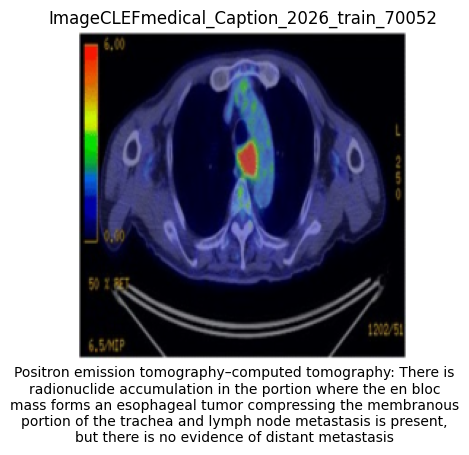

In [9]:
idx = random.randint(0, len(train_ds) - 1)
img, caption = train_ds[idx]

row = train_ds.data.iloc[idx]
img_name = row["ID"]

# If normalized, undo normalization for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_vis = img * std + mean   # undo normalization

# Convert from CHW (C,H,W) to HWC for plot
img_vis = img_vis.permute(1, 2, 0).numpy()
img_vis = img_vis.clip(0,1)  # values [0,1]

fig, ax = plt.subplots()
wrapped_caption = "\n".join(textwrap.wrap(caption, width=60))
ax.imshow(img_vis)
ax.set_title(f"{img_name}")
ax.axis("off")
plt.subplots_adjust(bottom=0.2)
fig.text(0.5, 0.02, wrapped_caption, ha='center', va='bottom', fontsize=10)
plt.show()

In [10]:
num_samples = 3

for _ in range(num_samples):
    idx = random.randint(0, len(train_ds) - 1)
    img, caption = train_ds[idx]

    row = train_ds.data.iloc[idx]
    img_name = row["ID"]

    print(f"Image ID: {img_name}")
    print(f"Image shape: {img.shape}")
    print(f"Image Caption: {caption}")
    print("-" * 50)

Image ID: ImageCLEFmedical_Caption_2026_train_7177
Image shape: torch.Size([3, 224, 224])
Image Caption: MRI revealed multiple formations in the liver parenchyma (October 2010)
--------------------------------------------------
Image ID: ImageCLEFmedical_Caption_2026_train_63721
Image shape: torch.Size([3, 224, 224])
Image Caption: X-ray detail of the invasive hemodynamic pacing study setup. The right atrial (RA), right ventricular (RV) and LV epicardial (LV-Epi) lead of the implanted system are shown, together with the temporary right atrial (RA-Temp) and LV endocardial electrode (LV-Endo). The RADI pressure wire is located in the LV cavity
--------------------------------------------------
Image ID: ImageCLEFmedical_Caption_2026_train_29168
Image shape: torch.Size([3, 224, 224])
Image Caption: Panoramic image 3 months postop.
--------------------------------------------------
